# Taller 6: Morfología matemática

In [1]:
PATH = './imagenes/'

## Cargue y visualice la imagen sic.png.

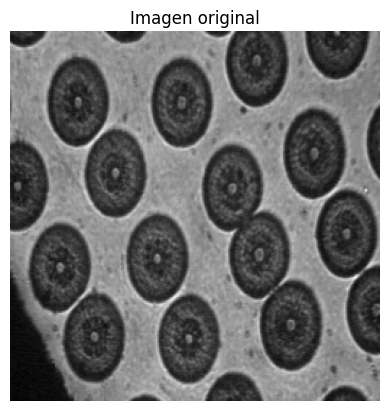

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = cv2.imread(PATH + 'SIC.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

## Umbralice esta imagen de forma tal que las células del fondo sean separadas (umbral entre 55 y 70), y calcule su negativo.

Binarizamos la imagen y calculamos el negativo.

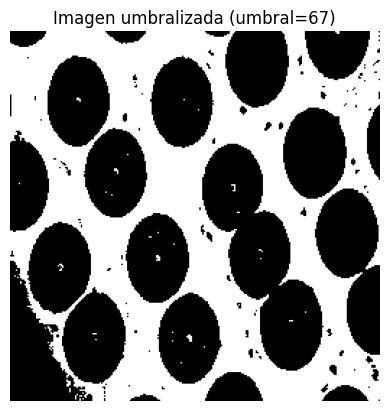

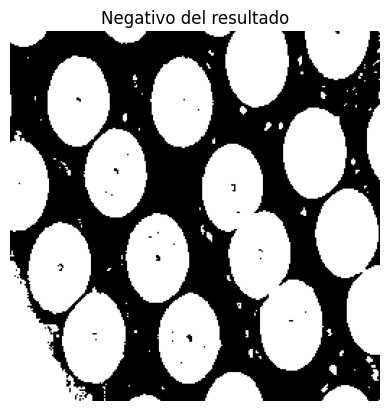

In [18]:
umbral = 67

_, imagen_umbralizada = cv2.threshold(imagen, umbral, 255, cv2.THRESH_BINARY)

plt.imshow(imagen_umbralizada, cmap='gray')
plt.title(f'Imagen umbralizada (umbral={umbral})')
plt.axis('off')
plt.show()

imagen_negativa = cv2.bitwise_not(imagen_umbralizada)

plt.imshow(imagen_negativa, cmap='gray')
plt.title('Negativo del resultado')
plt.axis('off')
plt.show()

## Con una máscara en cruz de 3x3, haga dilataciones para rellenar los huecos al interior de las células. 

In [19]:
fp = np.zeros((3, 3))
fp[1,:] = 1
fp[:,1] = 1
print("Elemento estructurante:")
print(fp)


Elemento estructurante:
[[0. 1. 0.]
 [1. 1. 1.]
 [0. 1. 0.]]


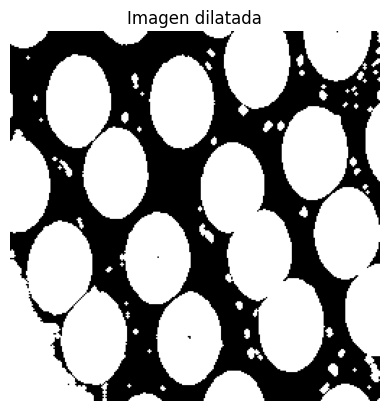

In [20]:
from skimage.morphology import dilation, erosion, footprint_rectangle

dilated_image = dilation(imagen_negativa, footprint=fp)
plt.imshow(dilated_image, cmap='gray')
plt.title('Imagen dilatada')
plt.axis('off')
plt.show()

La operación de dilatación con la cruz nos permite rellenar los círculos de las células.

## Cambie de máscaras: se utilizarán ahora máscaras lineales (oblicuas). Utilice las mismas máscaras oblicuas creadas en el punto de apertura y cierre de este taller. Con el operador de erosión, separe las diferentes células. Ayuda: Para separar las células es necesario erosionar por lo menos 10 veces con una máscara lineal oblicua (/) y 6 veces con una máscara ortogonal a la primera (\).

Creamos las máscaras diagonales (las mismas del notebook de apertura y cierre)

In [22]:
mascara_diag1 = np.array([[0, 0, 1],
                          [0, 1, 0],
                          [1, 0, 0]], dtype=bool)

mascara_diag2 = np.array([[1, 0, 0],
                          [0, 1, 0],
                          [0, 0, 1]], dtype=bool)

print("Máscara diagonal:")
print(mascara_diag1.astype(int))
print("\nMáscara diagonal:")
print(mascara_diag2.astype(int))

Máscara diagonal:
[[0 0 1]
 [0 1 0]
 [1 0 0]]

Máscara diagonal:
[[1 0 0]
 [0 1 0]
 [0 0 1]]


Aplicando 10 erosiones con máscara /
Erosión 1/10 completada
Erosión 2/10 completada
Erosión 3/10 completada
Erosión 4/10 completada
Erosión 5/10 completada
Erosión 6/10 completada
Erosión 7/10 completada
Erosión 8/10 completada
Erosión 9/10 completada
Erosión 10/10 completada


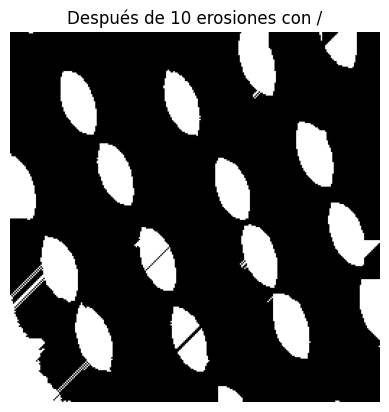

In [23]:
imagen_erosionada = dilated_image.copy()

# Aplicar erosión 10 veces con la máscara diagonal /
print("Aplicando 10 erosiones con máscara /")
for i in range(10):
    imagen_erosionada = erosion(imagen_erosionada, footprint=mascara_diag1)
    print(f"Erosión {i+1}/10 completada")

# Visualizar resultado intermedio
plt.imshow(imagen_erosionada, cmap='gray')
plt.title('Después de 10 erosiones con /')
plt.axis('off')
plt.show()

Aplicando 6 erosiones con máscara \
Erosión 1/6 completada
Erosión 2/6 completada
Erosión 3/6 completada
Erosión 4/6 completada
Erosión 5/6 completada
Erosión 6/6 completada


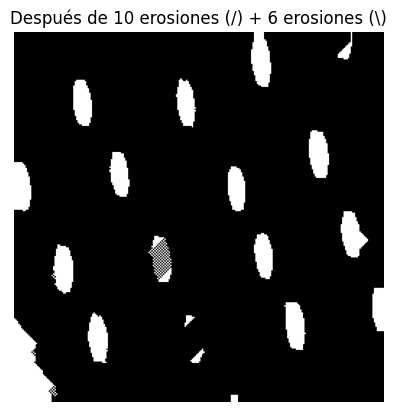

In [24]:
# Aplicar erosión 6 veces con la máscara diagonal \
print("Aplicando 6 erosiones con máscara \\")
for i in range(6):
    imagen_erosionada = erosion(imagen_erosionada, footprint=mascara_diag2)
    print(f"Erosión {i+1}/6 completada")

# Visualizar resultado final
plt.imshow(imagen_erosionada, cmap='gray')
plt.title('Después de 10 erosiones (/) + 6 erosiones (\\)')
plt.axis('off')
plt.show()

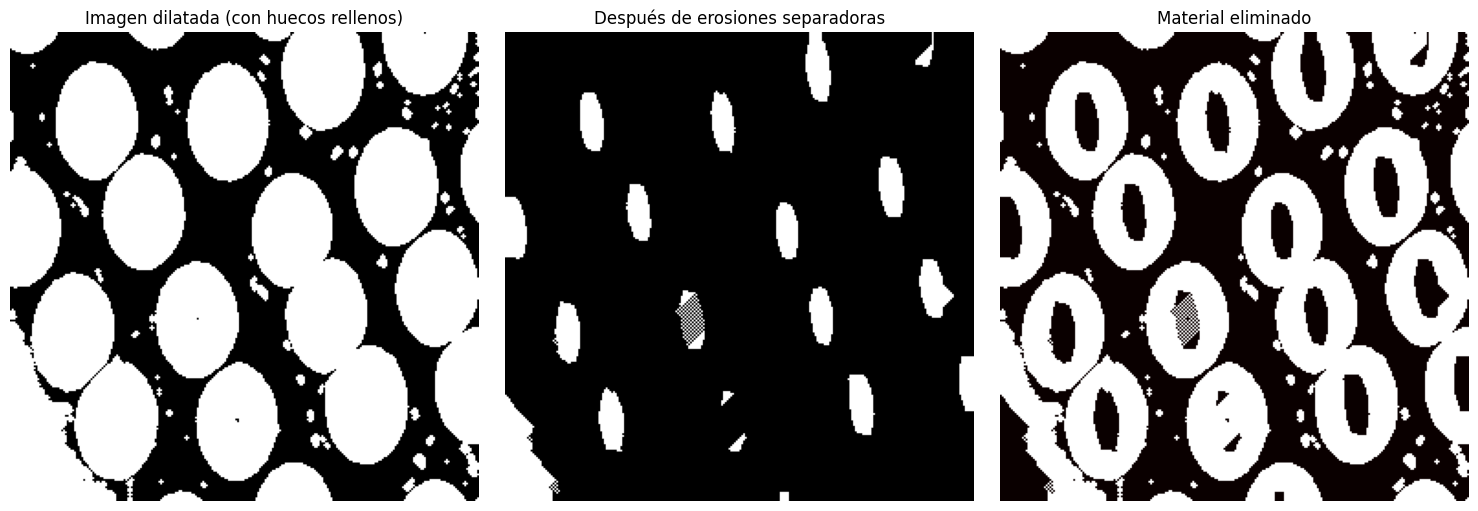

In [25]:
# Comparación: antes y después de las erosiones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(dilated_image, cmap='gray')
axes[0].set_title('Imagen dilatada (con huecos rellenos)')
axes[0].axis('off')

axes[1].imshow(imagen_erosionada, cmap='gray')
axes[1].set_title('Después de erosiones separadoras')
axes[1].axis('off')

# Diferencia
diferencia = dilated_image.astype(np.int16) - imagen_erosionada.astype(np.int16)
axes[2].imshow(diferencia, cmap='hot')
axes[2].set_title('Material eliminado')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Etiquete la imagen y visualice el resultado. Determine cuántas células enteras fueron detectadas ¿Qué ocurre con el borde?

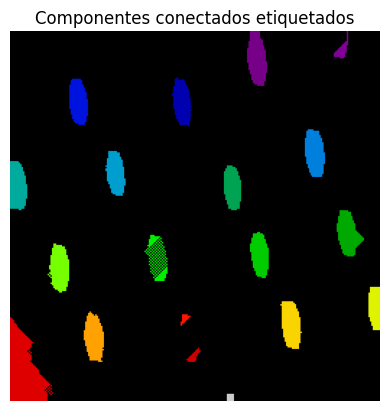

In [26]:
from skimage.measure import label

connected_components = label(imagen_erosionada, background=0, connectivity=2)
plt.imshow(connected_components, cmap='nipy_spectral')
plt.title('Componentes conectados etiquetados')
plt.axis('off')
plt.show()

 Se detectaron aproximadamente 14 entera. Una célula quedo incompleta y otras están cortada en la imagen. Las células enteras son principalmente las del centro de la imagen que no tocan los bordes. Las del borde están incompletas y su área no representa el tamaño real de una célula completa.